In [25]:
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver


from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

In [26]:
load_dotenv()

True

In [27]:
model = ChatOpenAI()

In [37]:
def chat(state: MessagesState):
    
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msg = state["messages"]
    
    # if more than 10 messages, delete the earliest 6
    if len(msg) > 10:
        to_remove = msg[:6]
        print(to_remove)
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}
    
    return {}

In [38]:
builder = StateGraph(MessagesState)
builder.add_node('chat', chat)
builder.add_node("cleanup", delete_old_messages)

In [39]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")
builder.add_edge("cleanup", END)

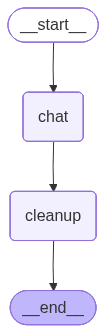

In [40]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [41]:
config = {"configurable": {"thread_id": "t1"}}

In [44]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method N

[HumanMessage(content="Hi, I'm Nitish", additional_kwargs={}, response_metadata={}, id='9671ee5d-b7f6-4456-b1eb-b1854ea0f984'), AIMessage(content='Nice to meet you Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 13, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Decc8Vf32v7RHuPZyLbC3FErqrh11', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e1b44-4f10-7560-aede-6b3819581b0f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 14, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


{'messages': [HumanMessage(content='Now explain checkpointers', additional_kwargs={}, response_metadata={}, id='ca446d45-75ca-427b-84d9-731d99a9ce8b'),
  AIMessage(content='Checkpointers is an essential feature of LangGraph that helps in saving the progress of the neural network model during training. It allows the model to save its current state, including weights, biases, and other parameters, at regular intervals or after a certain number of training iterations. This is crucial in deep learning tasks because training large neural networks can take a long time, and if the training process is interrupted or crashes, the model would lose all its learning progress. With checkpointing, the model can resume training from the last saved state instead of starting from scratch, saving time and computational resources. Checkpointing also enables researchers and data scientists to experiment with different hyperparameters and training configurations without losing the progress made by the mode

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [45]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 10
